# Qiskit Quick Refresher

A compact notebook for refreshing the Qiskit commands most likely to matter in an interview.

Target: **Qiskit 2.x-style APIs**.

Topics:
- circuits and gates
- Bell/GHZ states
- statevectors
- measurement and sampling
- Aer simulation
- transpilation
- parameterized circuits
- observables and expectation values
- simple variational loop
- noise model basics

## 0. Installation

Run this once in your environment if needed.

In [1]:
# %pip install -U qiskit qiskit-aer matplotlib

## 1. Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator, SparsePauliOp
from qiskit.circuit import Parameter, ParameterVector
from qiskit.primitives import StatevectorSampler, StatevectorEstimator

# Optional high-performance simulator
from qiskit_aer import AerSimulator

## 2. Build a basic quantum circuit

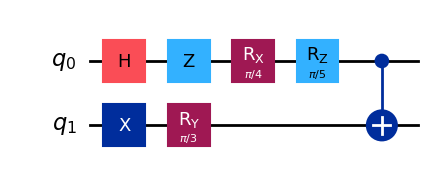

In [3]:
qc = QuantumCircuit(2)

qc.h(0)       # Hadamard
qc.x(1)       # Pauli-X
qc.z(0)       # Pauli-Z
qc.rx(np.pi/4, 0)
qc.ry(np.pi/3, 1)
qc.rz(np.pi/5, 0)

qc.cx(0, 1)   # CNOT: control=0, target=1

qc.draw("mpl")

### Common gates

```python
qc.x(q)
qc.y(q)
qc.z(q)

qc.h(q)
qc.s(q)
qc.sdg(q)
qc.t(q)

qc.rx(theta, q)
qc.ry(theta, q)
qc.rz(theta, q)

qc.cx(control, target)
qc.cz(control, target)
qc.swap(q1, q2)

qc.barrier()
qc.measure(q, c)
qc.measure_all()
```

## 3. Bell state

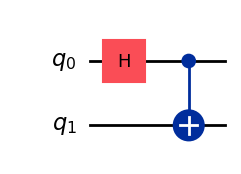

In [4]:
bell = QuantumCircuit(2)

bell.h(0)
bell.cx(0, 1)

bell.draw("mpl")

### Statevector

In [8]:
psi = Statevector(bell)

print(psi)                          # 1/sqrt(2) = 0.70
print("\nProbabilities:")
print(psi.probabilities_dict())
psi.draw("latex")

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Probabilities:
{np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


<IPython.core.display.Latex object>

### Plot state probabilities

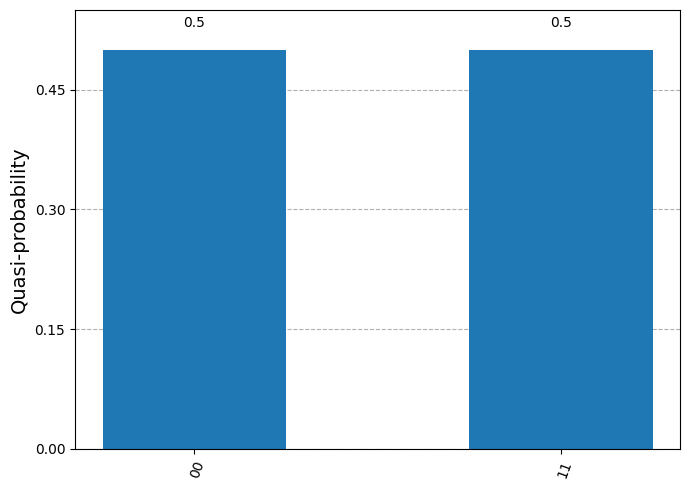

In [6]:
from qiskit.visualization import plot_distribution

plot_distribution(psi.probabilities_dict())

## 4. GHZ state

In [7]:
ghz = QuantumCircuit(3)

ghz.h(0)
ghz.cx(0, 1)
ghz.cx(1, 2)

Statevector(ghz).draw("latex")

<IPython.core.display.Latex object>

## 5. Measurement

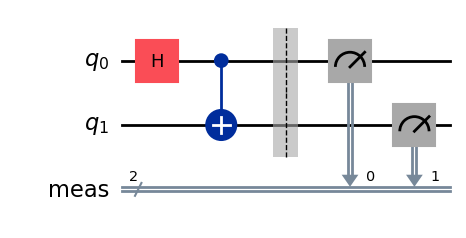

In [9]:
measured_bell = bell.copy()
measured_bell.measure_all()

measured_bell.draw("mpl")

## 6. StatevectorSampler

Modern Qiskit uses **Sampler** for sampled measurement outcomes.

Circuits passed to `StatevectorSampler` should contain measurements.

In [10]:
sampler = StatevectorSampler(default_shots=1000, seed=42)

job = sampler.run([measured_bell])
result = job.result()

pub_result = result[0]
print(pub_result)

SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1000, num_bits=2>)), metadata={'shots': 1000, 'circuit_metadata': {}})


The exact returned register name can depend on how the classical register was created.

For `measure_all()`, it is commonly `meas`.

In [11]:
counts = pub_result.data.meas.get_counts()

print(counts)

{'11': 497, '00': 503}


## 7. AerSimulator

In [12]:
simulator = AerSimulator()

compiled = transpile(measured_bell, simulator)

job = simulator.run(compiled, shots=1000)
result = job.result()

counts = result.get_counts()

print(counts)

{'11': 486, '00': 514}


### Plot counts

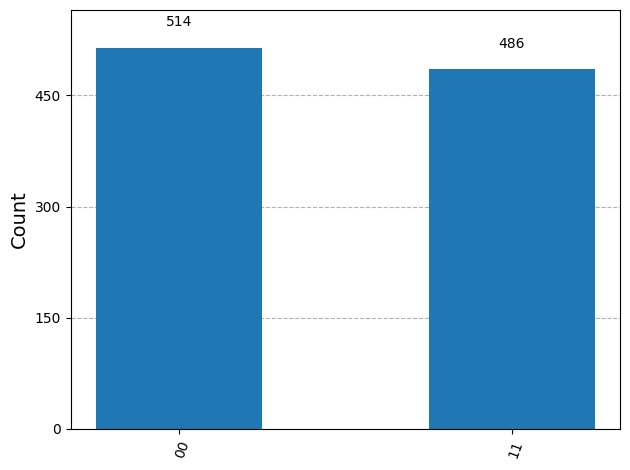

In [13]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

## 8. Unitary matrix of a circuit

In [20]:
unitary_circuit = QuantumCircuit(1)
unitary_circuit.h(0)

U = Operator(unitary_circuit)

print(U.data)

qc = QuantumCircuit(1)
qc.h(0)
qc.z(0)

U = Operator(qc)
print(U.data)

[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]
[[ 0.70710678+0.j  0.70710678+0.j]
 [-0.70710678+0.j  0.70710678+0.j]]


## 9. Parameterized quantum circuit

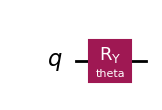

In [21]:
theta = Parameter("theta")

pqc = QuantumCircuit(1)
pqc.ry(theta, 0)

pqc.draw("mpl")

### Bind a parameter

In [24]:
bound = pqc.assign_parameters({theta: np.pi / 2})

print(bound)
print(Statevector(bound).probabilities_dict())

   ┌─────────┐
q: ┤ Ry(π/2) ├
   └─────────┘
{np.str_('0'): np.float64(0.5000000000000001), np.str_('1'): np.float64(0.5000000000000001)}


## 10. ParameterVector

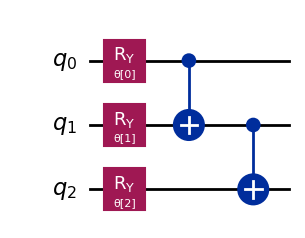

In [25]:
params = ParameterVector("θ", 3)

ansatz = QuantumCircuit(3)

for i in range(3):
    ansatz.ry(params[i], i)

ansatz.cx(0, 1)
ansatz.cx(1, 2)

ansatz.draw("mpl")

## 11. Expectation values with StatevectorEstimator

Estimator computes quantities like

$$
\langle \psi(\theta) | Observable | \psi(\theta) \rangle.
$$


In [26]:
theta = Parameter("theta")

qc = QuantumCircuit(1)
qc.ry(theta, 0)

observable = SparsePauliOp.from_list([
    ("Z", 1.0)
])

estimator = StatevectorEstimator()

job = estimator.run([
    (qc, observable, [np.pi / 3])
])

result = job.result()

print(result[0].data.evs)

0.5000000000000002


So here,

$$ H = Z = \begin{pmatrix} 1 & 0\\ 0 & -1 \end{pmatrix}. $$

The expectation value is therefore

$$ \langle \psi(\theta)|Z|\psi(\theta)\rangle. $$

For this particular circuit,

$$ R_y(\theta)|0\rangle = \cos\frac{\theta}{2}|0\rangle + \sin\frac{\theta}{2}|1\rangle. $$

So the probabilities are

$$ P(0)=\cos^2\frac{\theta}{2}, $$

and

$$ P(1)=\sin^2\frac{\theta}{2}. $$

Since \(Z\) gives eigenvalue \(+1\) for \(|0\rangle\) and \(-1\) for \(|1\rangle\),

$$ \langle Z\rangle = (+1)P(0)+(-1)P(1). $$

Therefore,

$$ \langle Z\rangle = \cos^2\frac{\theta}{2} - \sin^2\frac{\theta}{2} = \cos\theta. $$

So if you use

$$ \theta=\frac{\pi}{3}, $$

then

⟨Z⟩=cos
3
π
	​

=0.5.

## 12. Multiple Pauli terms / simple Hamiltonian

In [27]:
H = SparsePauliOp.from_list([
    ("ZI", 0.5),
    ("IZ", 0.5),
    ("XX", 0.2),
])

print(H)

SparsePauliOp(['ZI', 'IZ', 'XX'],
              coeffs=[0.5+0.j, 0.5+0.j, 0.2+0.j])


## 13. Variational ansatz

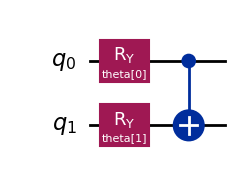

In [28]:
theta = ParameterVector("theta", 2)

ansatz = QuantumCircuit(2)

ansatz.ry(theta[0], 0)
ansatz.ry(theta[1], 1)
ansatz.cx(0, 1)

ansatz.draw("mpl")

### Define a cost function

In [ ]:
estimator = StatevectorEstimator()

H = SparsePauliOp.from_list([
    ("ZI", 1.0),
    ("IZ", 1.0),
    ("XX", 0.5)
])

def cost_function(values):
    job = estimator.run([
        (ansatz, H, values)
    ])
    result = job.result()
    return float(result[0].data.evs)

print(cost_function([0.1, 0.2]))

### Optimize classically

In [ ]:
from scipy.optimize import minimize

x0 = np.array([0.2, 0.7])

opt_result = minimize(
    cost_function,
    x0,
    method="COBYLA"
)

print("Optimal parameters:", opt_result.x)
print("Minimum energy:", opt_result.fun)

This is the basic hybrid variational pattern:

\[
\theta
\rightarrow
U(\theta)
\rightarrow
\langle H \rangle
\rightarrow
\text{classical optimizer}
\rightarrow
\theta'
\]

## 14. Data encoding example

In [ ]:
x = np.array([0.3, -0.8])

feature_map = QuantumCircuit(2)

feature_map.ry(x[0], 0)
feature_map.ry(x[1], 1)
feature_map.cx(0, 1)

feature_map.draw("mpl")

## 15. Angle encoding + trainable layer

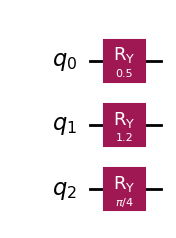

In [ ]:
# Example 1: Angle Encoding (simplest)

from qiskit import QuantumCircuit
import numpy as np

def angle_feature_map(x):
    """Encode 3 classical features into 3 qubits using RY rotations."""
    qc = QuantumCircuit(3, name="FeatureMap")
    for i, xi in enumerate(x):
        qc.ry(xi, i)      # rotate qubit i by angle xi
    return qc

# Example data point
x = [0.5, 1.2, np.pi/4]
qc = angle_feature_map(x)
qc.draw('mpl')

C:\Users\meisa\AppData\Local\Temp\ipykernel_49624\616422677.py:4: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  fm = ZZFeatureMap(feature_dimension=3, reps=2, entanglement='linear')


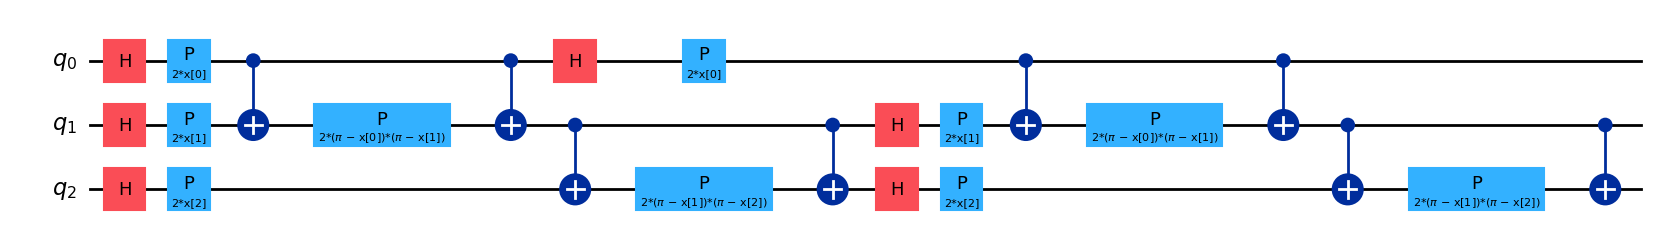

In [35]:
from qiskit.circuit.library import ZZFeatureMap

# feature_dimension = number of classical features = number of qubits
fm = ZZFeatureMap(feature_dimension=3, reps=2, entanglement='linear')
fm.decompose().draw('mpl')

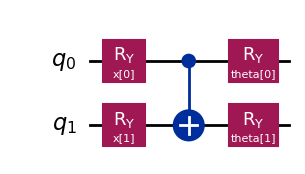

In [31]:
x = ParameterVector("x", 2)
theta = ParameterVector("theta", 2)

qml_circuit = QuantumCircuit(2)

# Encode classical features
qml_circuit.ry(x[0], 0)
qml_circuit.ry(x[1], 1)

# Entanglement
qml_circuit.cx(0, 1)

# Trainable variational layer
qml_circuit.ry(theta[0], 0)
qml_circuit.ry(theta[1], 1)

qml_circuit.draw("mpl")

## 16. Basic transpilation

In [ ]:
qc = QuantumCircuit(3)

qc.h(0)
qc.cx(0, 2)

print("Original circuit:")
print(qc)

transpiled_qc = transpile(
    qc,
    basis_gates=["rz", "sx", "x", "cx"],
    optimization_level=3
)

print("\nTranspiled circuit:")
print(transpiled_qc)

Useful transpiler arguments:

```python
transpile(
    circuit,
    backend=backend,
    optimization_level=0  # 0, 1, 2, 3
)
```

Higher optimization levels generally perform more circuit optimization but require more compilation effort.

## 17. Circuit depth and gate counts

In [ ]:
print("Depth:", transpiled_qc.depth())
print("Gate counts:", transpiled_qc.count_ops())
print("Number of qubits:", transpiled_qc.num_qubits)
print("Number of parameters:", transpiled_qc.num_parameters)

## 18. Circuit composition

In [ ]:
encoder = QuantumCircuit(2)
encoder.h(0)
encoder.cx(0, 1)

layer = QuantumCircuit(2)
layer.ry(0.4, 0)
layer.ry(0.8, 1)

full_circuit = encoder.compose(layer)

full_circuit.draw("mpl")

## 19. Inverse circuit

In [ ]:
qc = QuantumCircuit(1)
qc.h(0)
qc.rz(0.3, 0)

inverse_qc = qc.inverse()

identity_test = qc.compose(inverse_qc)

identity_test.draw("mpl")

## 20. Noise simulation basics

In [ ]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

noise_model = NoiseModel()

error_1q = depolarizing_error(0.01, 1)
error_2q = depolarizing_error(0.03, 2)

noise_model.add_all_qubit_quantum_error(
    error_1q,
    ["h", "x", "rx", "ry", "rz"]
)

noise_model.add_all_qubit_quantum_error(
    error_2q,
    ["cx"]
)

noisy_simulator = AerSimulator(noise_model=noise_model)

In [ ]:
noisy_bell = QuantumCircuit(2)
noisy_bell.h(0)
noisy_bell.cx(0, 1)
noisy_bell.measure_all()

compiled = transpile(noisy_bell, noisy_simulator)

counts = noisy_simulator.run(
    compiled,
    shots=2000
).result().get_counts()

print(counts)
plot_histogram(counts)

## 21. Density matrix

In [ ]:
from qiskit.quantum_info import DensityMatrix

qc = QuantumCircuit(1)
qc.h(0)

rho = DensityMatrix(qc)

print(rho)
print(rho.data)

## 22. Partial trace / reduced state

In [ ]:
from qiskit.quantum_info import partial_trace

bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

psi = Statevector(bell)

rho_qubit_0 = partial_trace(psi, [1])

print(rho_qubit_0)

For a maximally entangled Bell state, each individual qubit is maximally mixed:

\[
\rho_0 =
\frac{1}{2}
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}.
\]

## 23. Fidelity

In [ ]:
from qiskit.quantum_info import state_fidelity

qc1 = QuantumCircuit(1)
qc1.h(0)

qc2 = QuantumCircuit(1)
qc2.ry(np.pi / 2, 0)

psi1 = Statevector(qc1)
psi2 = Statevector(qc2)

print("Fidelity =", state_fidelity(psi1, psi2))

## 24. Very quick interview cheat sheet

### Circuit

```python
qc = QuantumCircuit(n)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
```

### Statevector

```python
psi = Statevector(qc_without_measurements)
psi.probabilities_dict()
```

### Sampling

```python
sampler = StatevectorSampler()
result = sampler.run([qc_with_measurements]).result()
counts = result[0].data.meas.get_counts()
```

### Aer

```python
backend = AerSimulator()
qc_t = transpile(qc, backend)
counts = backend.run(qc_t, shots=1000).result().get_counts()
```

### Parameters

```python
theta = Parameter("theta")
qc.ry(theta, 0)
qc.assign_parameters({theta: 0.5})
```

### Observable

```python
H = SparsePauliOp.from_list([
    ("Z", 1.0)
])
```

### Expectation value

```python
estimator = StatevectorEstimator()
result = estimator.run([
    (qc, H, [theta_value])
]).result()

energy = result[0].data.evs
```

### Transpile

```python
qc_t = transpile(
    qc,
    backend,
    optimization_level=3
)
```

## 25. Concepts worth being able to explain aloud

For the Quandela interview, don't just remember syntax. Be able to explain:

- superposition vs classical mixture
- entanglement
- measurement and shots
- Bloch sphere
- unitary evolution
- expectation values
- parameterized quantum circuits
- quantum feature maps
- variational quantum algorithms
- quantum kernels
- barren plateaus
- shot noise
- hardware noise
- transpilation
- circuit depth
- connectivity constraints
- classical vs quantum baselines
- why a larger Hilbert space does **not automatically imply quantum advantage**